# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

In [2]:
import pandas as pd 
import numpy as np

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS, WLS

from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['text.usetex'] = False

In [5]:
from core.variables import * 
from core.estimators import *
from core.dgp import *
from core.experiments import *
from core.visualization import *

# Experiments

In [6]:
# parameters
train_size = 100
test_size = 10
num_groups = 2
te_diff = 0.1
group_func = lambda x: 0 if x < 0 else 1

# initialize the data generating process
dgp = DGP1(
    num_groups=num_groups, te_diff=te_diff, group_func=group_func, noise_std=1.0, treatment_assign_prob=0.5
)

train_x, train_t, train_y = dgp.generate_training_data(train_size)
test_x = dgp.generate_testing_data(test_size)

# train estimators 
plugin_estimator = BinaryPlugIn(dgp.group_func, num_groups).fit(train_x, train_t, train_y)  # plugin estimator
corr_estimator = BinaryCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500)  # bootstrap correction estimator
mnb_corr_estimator = BinaryMNBCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500, q=0.9, max_j=20)  # m-out-of-n bootstrap correction estimator
adj_corr_estimator = BinaryAdjustedCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=5000)  # adjusted bootstrap correction estimator
# pb_corr_estimator = BinaryPBCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y)  # parametric bootstrap correction estimator
# bb_corr_estimator = BinaryBBCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y)  # non-parametric bootstrap correction estimator
# mnb_corr_estimator = BinaryMNBootCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y)  # m-out-of-n bootstrap correction estimator
# param_estimator = BinaryParametric(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y)  # parametric estimator

In [7]:
# evalute test set 
budget = 1

best_targ_val = get_best_targeting_val(test_x, dgp, budget=budget)
plugin_targ_est = plugin_estimator.estimate_targeting_value(test_x, budget=budget)
true_plugin_targ_val = evaluate_targeting_policy(test_x, plugin_estimator.get_targeting_decision(test_x, budget), dgp, budget=budget)
correction_target_est = corr_estimator.estimate_targeting_value(test_x, budget=budget)
adj_corr_target_est = adj_corr_estimator.estimate_targeting_value(test_x, budget=budget)
# pb_corr_target_est = pb_corr_estimator.estimate_targeting_value(test_x, budget=budget)
# bb_corr_target_est = bb_corr_estimator.estimate_targeting_value(test_x, budget=budget)
mnb_corr_target_est = mnb_corr_estimator.estimate_targeting_value(test_x, budget=budget)
# param_target_est = param_estimator.estimate_targeting_value(test_x, budget=budget)

print(f"Best targeting value: {best_targ_val:.4f}\n")

print(f"Plugin targeting estimate: {plugin_targ_est:.4f}")
print(f"Correction targeting estimate: {correction_target_est:.4f}")
print(f"Adjusted correction targeting estimate: {adj_corr_target_est:.4f}")
# print(f"Parametric bootstrap targeting estimate: {pb_corr_target_est:.4f}")
# print(f"Bayesian bootstrap targeting estimate: {bb_corr_target_est:.4f}")
print(f"M-out-of-n bootstrap targeting estimate: {mnb_corr_target_est:.4f}")
# print(f"Parametric targeting estimate: {param_target_est:.4f}")

print(f"\nActual value of plugin targeting: {true_plugin_targ_val:.4f}")
print(f"Winner's Curse of plugin estimate: {plugin_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of correction estimat: {correction_target_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of adjusted correction estimate: {adj_corr_target_est - true_plugin_targ_val:.4f}")
# print(f"Winner's Curse of parametric bootstrap estimate: {pb_corr_target_est - true_plugin_targ_val:.4f}")
# print(f"Winner's Curse of Bayesian bootstrap estimate: {bb_corr_target_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of M-out-of-n bootstrap estimate: {mnb_corr_target_est - true_plugin_targ_val:.4f}")
# print(f"Winner's Curse of parametric estimate: {param_target_est - true_plugin_targ_val:.4f}")

Best targeting value: 1.1000

Plugin targeting estimate: 1.1400
Correction targeting estimate: 1.0296
Adjusted correction targeting estimate: 1.0817
M-out-of-n bootstrap targeting estimate: 0.9992

Actual value of plugin targeting: 1.1000
Winner's Curse of plugin estimate: 0.0400
Winner's Curse of correction estimat: -0.0704
Winner's Curse of adjusted correction estimate: -0.0183
Winner's Curse of M-out-of-n bootstrap estimate: -0.1008


## Test 1

In [8]:
# parameters
dgp_params = {
    'num_groups': 2,  # number of groups
    'te_diff': 0.1,  # treatment effect difference
    'group_func': lambda x: 0 if x < 0 else 1,  # group function
    'train_size': 100,  # size of training set
    'noise_std': 1.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstraps': 1000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    # 'adj_correction': {
    #     'estimator': BinaryAdjustedCorrection, 
    #     'train_params': {'n_bootstraps': 1000},
    #     'targeting_params': {},
    # },  # adjusted bootstrap correction estimator, 
    # 'pb_correction': {
    #     'estimator': BinaryPBCorrection, 
    #     'train_params': {},
    #     'targeting_params': {'n_bootstraps': 1000},
    # },  # parametric bootstrap correction estimator
    # 'bb_correction': {
    #     'estimator': BinaryBBCorrection, 
    #     'train_params': {'n_bootstraps': 1000},
    #     'targeting_params': {},
    # },  # non-parametric bootstrap correction estimator
    'mnb_correction': {
        'estimator': BinaryMNBCorrection, 
        'train_params': {'n_bootstraps': 1000, 'q': 0.9, 'max_j': 20},
        'targeting_params': {},
    },  # m-out-of-n bootstrap correction estimator
    # 'parametric': {
    #     'estimator': BinaryParametric, 
    #     'train_params': {},
    #     'targeting_params': {},
    # },  # parametric estimator
}

In [18]:
grid_results = grid_experiment(
    sample_sizes=[100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000],  
    num_bootstraps=[500],
    noise_stds=[1.0],
    te_diffs=[0.1], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/sample_size_test.csv',
    num_test_groups=25, num_repeats_per_test_group=50, 
    verbose=True
)

Fixed knob values: 
num_bootstrap=500
noise_std=1.0
te_diff=0.1
sample_size=100.0, Time taken: 0:16:01.561226
sample_size=200.0, Time taken: 0:16:38.276629


KeyboardInterrupt: 

Fixed Knobs:  num_bootstrap: 500.0, noise_std: 1.0, te_diff: 0.1, 

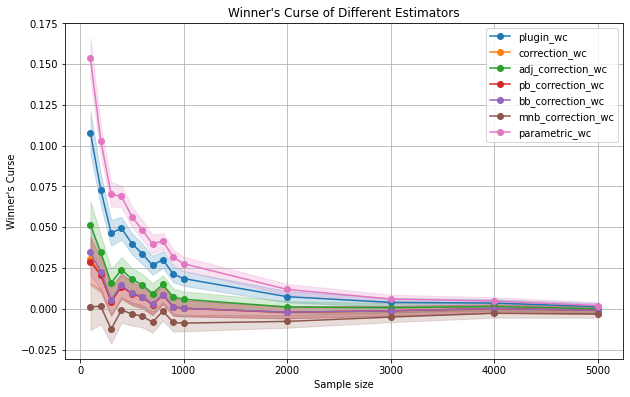

In [20]:
plot_winners_curse_2d(
    'results/sample_size_test.csv', 
    x='sample_size', confidence_level=0.95, 
)

Fixed Knobs:  num_bootstrap: 500.0, noise_std: 1.0, te_diff: 0.1, 

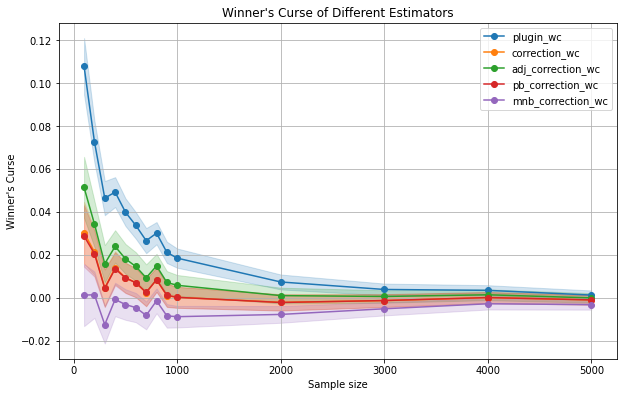

In [21]:
plot_winners_curse_2d(
    'results/sample_size_test.csv', 
    x='sample_size', confidence_level=0.95, 
    estimators=['plugin', 'correction', 'adj_correction', 'pb_correction', 'mnb_correction']
)

In [11]:
grid_results = grid_experiment(
    sample_sizes=[1000], 
    num_bootstraps=[1000],
    noise_stds=[1.0],
    te_diffs=[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/te_diff_test.csv',
    num_test_groups=25, num_repeats_per_test_group=50, 
    verbose=True
)

Fixed knob values: 
sample_size=1000
num_bootstrap=1000
noise_std=1.0
te_diff=0.05, Time taken: 0:19:32.370260
te_diff=0.1, Time taken: 0:19:35.272520
te_diff=0.15, Time taken: 0:19:21.236115
te_diff=0.2, Time taken: 0:18:48.787112
te_diff=0.25, Time taken: 0:18:17.428766
te_diff=0.3, Time taken: 0:17:23.651810
te_diff=0.35, Time taken: 0:16:48.781206
te_diff=0.4, Time taken: 0:16:16.667947
te_diff=0.45, Time taken: 0:16:03.825968
te_diff=0.5, Time taken: 0:15:49.728008


Fixed Knobs:  sample_size: 1000.0, num_bootstrap: 1000.0, noise_std: 1.0, 

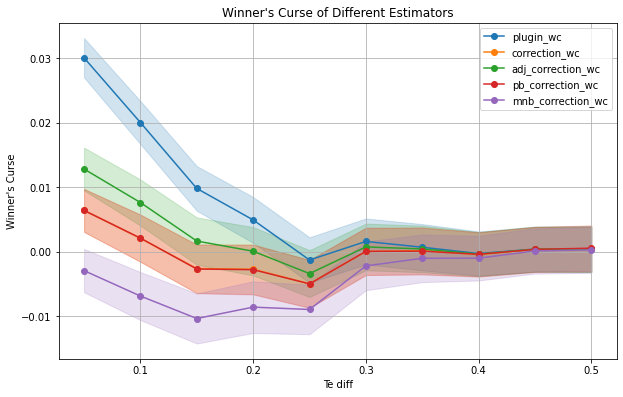

In [22]:
plot_winners_curse_2d(
    'results/te_diff_test.csv', 
    x='te_diff', confidence_level=0.95, 
    estimators=['plugin', 'correction', 'adj_correction', 'pb_correction', 'mnb_correction']
)

In [13]:
grid_results = grid_experiment(
    sample_sizes=[1000], 
    num_bootstraps=[1000],
    noise_stds=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    te_diffs=[0.1], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/noise_std_test.csv',
    num_test_groups=25, num_repeats_per_test_group=50, 
    verbose=True
)

Fixed knob values: 
sample_size=1000
num_bootstrap=1000
te_diff=0.1
noise_std=0.5, Time taken: 0:18:51.571336
noise_std=1.0, Time taken: 0:19:31.541217
noise_std=1.5, Time taken: 0:19:33.501919
noise_std=2.0, Time taken: 0:19:30.452714
noise_std=2.5, Time taken: 0:19:31.248806
noise_std=3.0, Time taken: 0:19:26.849934
noise_std=3.5, Time taken: 0:19:32.569413
noise_std=4.0, Time taken: 0:19:31.560173
noise_std=4.5, Time taken: 0:19:30.762510
noise_std=5.0, Time taken: 0:19:34.757635


Fixed Knobs:  sample_size: 1000.0, num_bootstrap: 1000.0, te_diff: 0.1, 

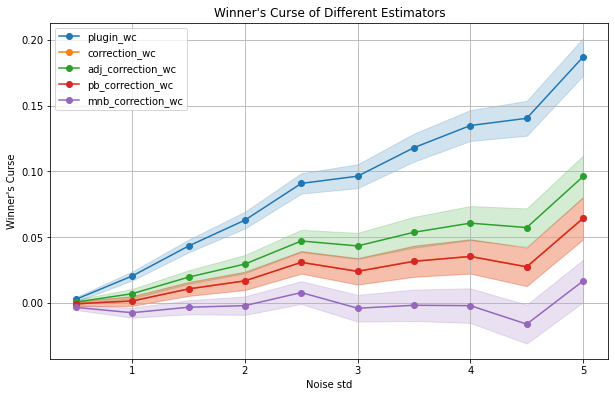

In [24]:
plot_winners_curse_2d(
    'results/noise_std_test.csv', 
    x='noise_std', confidence_level=0.95, 
    estimators=['plugin', 'correction', 'adj_correction', 'pb_correction', 'mnb_correction']
)

## Test 2

In [ ]:
# parameters
def group_func(x):
    if x <= -1.5:
        return 0
    elif x <= 0:
        return 1
    elif x <= 1.5:
        return 2
    else:
        return 3
    
# parameters
dgp_params = {
    'num_groups': 4,  # number of groups
    'te_diff': 0.1,  # treatment effect difference
    'group_func': group_func,  # group function
    'train_size': 100,  # size of training set
    'noise_std': 1.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 20,  # number of arriving customers
    'budget': 5,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 1000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 1000},
        'targeting_params': {},
    },  # adjusted bootstrap correction estimator, 
}

In [ ]:
grid_results = grid_experiment(
    sample_sizes=[100, 200, 300, 400, 500, 1000, 2000, 3000, 4000, 5000], 
    num_bootstraps=[500],
    noise_stds=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    te_diffs=[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/wc_grid2.csv',
    num_repeats=50, verbose=True
)

Sample size: 100, Num bootstrap: 5000, Time taken: 169.08 seconds
Sample size: 100, Num bootstrap: 10000, Time taken: 338.05 seconds
Sample size: 100, Num bootstrap: 15000, Time taken: 518.35 seconds
Sample size: 100, Num bootstrap: 20000, Time taken: 686.76 seconds
Sample size: 500, Num bootstrap: 5000, Time taken: 175.74 seconds
Sample size: 500, Num bootstrap: 10000, Time taken: 361.12 seconds
Sample size: 500, Num bootstrap: 15000, Time taken: 541.05 seconds
Sample size: 500, Num bootstrap: 20000, Time taken: 717.27 seconds
Sample size: 1000, Num bootstrap: 5000, Time taken: 186.74 seconds
Sample size: 1000, Num bootstrap: 10000, Time taken: 2289.31 seconds
Sample size: 1000, Num bootstrap: 15000, Time taken: 1538.88 seconds
Sample size: 1000, Num bootstrap: 20000, Time taken: 775.34 seconds
Sample size: 1500, Num bootstrap: 5000, Time taken: 197.85 seconds
Sample size: 1500, Num bootstrap: 10000, Time taken: 399.24 seconds
Sample size: 1500, Num bootstrap: 15000, Time taken: 607.1

# Sketch

In [75]:
# parameters
train_size = 100
test_size = 10
num_groups = 2
te_diff = 0.1
group_func = lambda x: 0 if x < 0 else 1

# initialize the data generating process
dgp = DGP1(
    num_groups=num_groups, te_diff=te_diff, group_func=group_func, noise_std=1.0, treatment_assign_prob=0.5
)

train_x, train_t, train_y = dgp.generate_training_data(train_size)
test_x = dgp.generate_testing_data(test_size)

In [237]:
# helper functions
def calculate_binary_treatment_effect_per_group(
        group: np.ndarray, t: np.ndarray, y: np.ndarray, n_groups: int
) -> list:
    """ 
    This function calculates the treatment effect per group with binary treatments. 

    params:
    ------
    group: np.ndarray (None, 1)
        The group assignment of each customer.
    t: np.ndarray (None, 1)
        The treatment assignment of each customer.
    y: np.ndarray (None, 1)
        The outcome of each customer.
    """
    treated_counts = [
        (t[group == group_id] == 1).sum() for group_id in range(n_groups)
    ]  # number of treated customers per group
    control_counts = [
        (t[group == group_id] == 0).sum() for group_id in range(n_groups)
    ]  # number of control customers per group

    # check if there are any groups with no treated or control customers
    if any([treated_counts[i] == 0 or control_counts[i] == 0 for i in range(n_groups)]):
        return [np.nan, np.nan]

    # calculate the treatment effect per group
    te_list = [
        y[group == group_id][t[group == group_id] == 1].mean() - y[group == group_id][t[group == group_id] == 0].mean()
        for group_id in range(n_groups)
    ]

    return te_list

In [290]:
# parameters
q = 0.9 
max_j = 20
num_bootstraps = 1000
x = train_x.copy()
y = train_y.copy()
t = train_t.copy()

budget = 1

# get customer groups
group_arr = np.array([group_func(x_i) for x_i in x])

# calculate the sample sizes 
sample_size = x.shape[0] 
m_arr = np.array([int(q**j * sample_size) for j in range(max_j)])
stats_dstn_list = [None] * m_arr.shape[0]

# calculate empirical potential outcomes
emp_te_arr = np.array(calculate_binary_treatment_effect_per_group(group_arr, t, y, num_groups))

# create bootstraps
for i, m in enumerate(m_arr):
    # bootstrap sample indices, shape (num_bootstraps, m)
    boot_index_arr = np.random.choice(np.arange(sample_size), size=(num_bootstraps, m), replace=True)  
    
    boot_y_arr = y.flatten()[boot_index_arr]
    boot_t_arr = t.flatten()[boot_index_arr]
    boot_group_arr = group_arr.flatten()[boot_index_arr]

    # calculate the treatment effect per group for each bootstrap sample
    boot_te_arr = np.array([calculate_binary_treatment_effect_per_group(
        group=boot_group_arr[boot_id, :], t=boot_t_arr[boot_id, :], y=boot_y_arr[boot_id, :], n_groups=2
    ) for boot_id in range(num_bootstraps)])

    # keep only the rows with no NaN values
    boot_te_arr = boot_te_arr[~np.isnan(boot_te_arr).any(axis=1)]

    # calculate empirical estimation error
    xi_arr = boot_te_arr - emp_te_arr

    # calculate correction terms per bootstrap sample
    test_group_arr = np.array([group_func(x) for x in test_x])
    boot_est_arr = boot_te_arr[:, test_group_arr]
    xi_arr = xi_arr[:, test_group_arr]
    # create a mask to identify the treated individuals within each bootstrap sample
    # if the treatment effect estimate is among the largests, the mask is 1, otherwise 0
    # if ties, select the ones with smaller indexes
    mask_arr = np.zeros_like(boot_est_arr)
    # sort the treatment effect estimates in descending order for each bootstrap sample
    sorted_columns = np.argsort(-boot_est_arr, axis=1)[:, :budget]

    # set the mask to 1 for the treated individuals
    rows = np.repeat(np.arange(boot_est_arr.shape[0])[:, None], budget, axis=1)
    mask_arr[rows, sorted_columns] = 1

    stats_dstn_list[i] = np.sum(mask_arr * xi_arr, axis=1)

In [292]:
discp_list = [None] * (m_arr.shape[0] - 1)
for idx, (prev_dstn, current_dstn) in enumerate(zip(stats_dstn_list[:-1], stats_dstn_list[1:])):
    ks_stat, p_value = ks_2samp(prev_dstn, current_dstn)
    print(f"m={m_arr[idx]}, KS statistic: {ks_stat:.4f}, p-value: {p_value:.4f}")
    discp_list[idx] = ks_stat

min_discp_idx = np.argmin(discp_list)
chosen_m = m_arr[min_discp_idx]

print(f"Minimum discrepancy = {discp_list[min_discp_idx]:.4f} at m={chosen_m}")

m=100, KS statistic: 0.0310, p-value: 0.7228
m=90, KS statistic: 0.0510, p-value: 0.1484
m=81, KS statistic: 0.0700, p-value: 0.0149
m=72, KS statistic: 0.0390, p-value: 0.4326
m=65, KS statistic: 0.0300, p-value: 0.7594
m=59, KS statistic: 0.0440, p-value: 0.2878
m=53, KS statistic: 0.0360, p-value: 0.5363
m=47, KS statistic: 0.0430, p-value: 0.3137
m=43, KS statistic: 0.0280, p-value: 0.8282
m=38, KS statistic: 0.0650, p-value: 0.0292
m=34, KS statistic: 0.0460, p-value: 0.2407
m=31, KS statistic: 0.0367, p-value: 0.4948
m=28, KS statistic: 0.0393, p-value: 0.4136
m=25, KS statistic: 0.0652, p-value: 0.0275
m=22, KS statistic: 0.0448, p-value: 0.2651
m=20, KS statistic: 0.0331, p-value: 0.6403
m=18, KS statistic: 0.0537, p-value: 0.1176
m=16, KS statistic: 0.0271, p-value: 0.8605
m=15, KS statistic: 0.0466, p-value: 0.2550
Minimum discrepancy = 0.0271 at m=16
